In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("mental_health_synthetic_dataset_10k.csv")
print("Shape:", df.shape)
df.head()


Shape: (100000, 66)


,profile,language,total_word_count,unique_word_count,ttr,positive_emotion_ratio,negative_emotion_ratio,fear_word_frequency,sadness_word_frequency,anger_word_frequency,...,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,target
0,Anxiety,hindi,235,89,0.381756,0.064686,0.037008,0.000354,0.055044,0.022693,...,1.233143,-0.636224,0.870540,-0.466693,0.688440,-0.358205,-0.292142,-0.784100,1.124888,Anxiety
1,Suicidal_Tendency,hindi,290,100,0.346952,0.009382,0.131158,0.011196,0.186946,0.029341,...,0.355338,0.501002,0.957545,0.537179,-0.856195,1.084053,-0.413976,-1.062431,-0.394575,Suicidal_Tendency
2,Bipolar_Mania,english,281,104,0.372091,0.010993,0.062430,0.052428,0.004622,0.039678,...,0.465631,0.799562,-1.040073,0.591067,2.597825,0.866207,0.600295,-0.325673,1.419401,Bipolar_Mania
3,Stress,hindi,287,141,0.492944,0.068310,0.122438,0.021575,0.066394,0.028111,...,1.414007,-2.255789,-0.113184,-1.228702,0.800568,0.430139,0.840404,1.485844,1.517951,Stress
4,Depression,english,206,132,0.643964,0.018720,0.113168,0.007220,0.087223,0.000832,...,-1.042932,-0.724612,1.088175,-0.427495,2.774622,1.196945,-1.238697,0.067767,1.289753,Depression


Class                     Count  % of total
--------------------------------------------
Depression                25046       25.0%
Stress                    20060       20.1%
Anxiety                   19932       19.9%
Bipolar_Mania             15057       15.1%
Phobia                    10079       10.1%
Suicidal_Tendency          9826        9.8%
--------------------------------------------
Total                    100000

Imbalance ratio (max/min): 2.55x


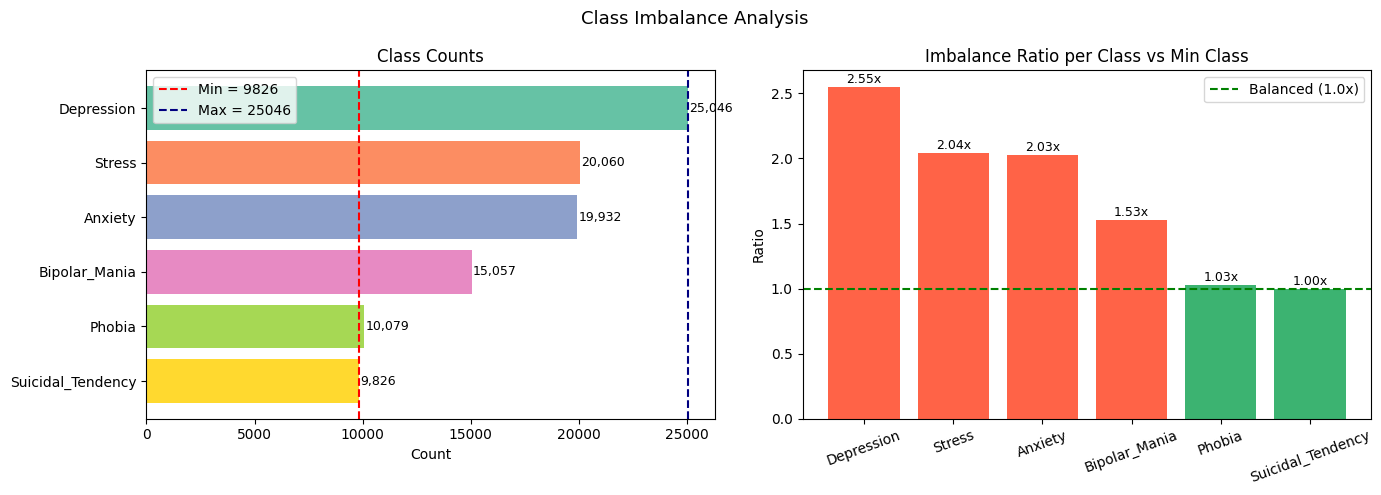

In [3]:
# Class Imbalance Analysis
counts = df["target"].value_counts().sort_values(ascending=False)
max_class = counts.max()
min_class = counts.min()
imbalance_ratio = max_class / min_class

print(f"{'Class':<22} {'Count':>8}  {'% of total':>10}")
print("-" * 44)
for cls, cnt in counts.items():
    rel = cnt / counts.sum() * 100
    print(f"{cls:<22} {cnt:>8}  {rel:>9.1f}%")
print("-" * 44)
print(f"{'Total':<22} {counts.sum():>8}")
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("Set2", len(counts))

bars = axes[0].barh(counts.index[::-1], counts.values[::-1], color=palette[::-1])
axes[0].axvline(min_class, color="red", linestyle="--", linewidth=1.5, label=f"Min = {min_class}")
axes[0].axvline(max_class, color="navy", linestyle="--", linewidth=1.5, label=f"Max = {max_class}")
axes[0].set_title("Class Counts")
axes[0].set_xlabel("Count")
axes[0].legend()
for bar, v in zip(bars, counts.values[::-1]):
    axes[0].text(v + 50, bar.get_y() + bar.get_height() / 2, f"{v:,}", va="center", fontsize=9)

ratios = (counts / min_class).round(2)
color_map = ["tomato" if r > 1.5 else "gold" if r > 1.1 else "mediumseagreen" for r in ratios.values]
axes[1].bar(ratios.index, ratios.values, color=color_map)
axes[1].axhline(1.0, color="green", linestyle="--", linewidth=1.5, label="Balanced (1.0x)")
for i, (cls, r) in enumerate(ratios.items()):
    axes[1].text(i, r + 0.03, f"{r:.2f}x", ha="center", fontsize=9)
axes[1].set_title("Imbalance Ratio per Class vs Min Class")
axes[1].set_ylabel("Ratio")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.suptitle("Class Imbalance Analysis", fontsize=13)
plt.tight_layout()
plt.show()


In [4]:
# Random Undersampling — downsample every class to the size of the smallest class
n_min = df["target"].value_counts().min()
print(f"Undersampling to {n_min} rows per class")

df_balanced = (
    df.groupby("target", group_keys=False)
      .apply(lambda g: g.sample(n=n_min, random_state=42))
      .reset_index(drop=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print(f"Original  : {df.shape[0]:,} rows")
print(f"Balanced  : {df_balanced.shape[0]:,} rows")
print(f"Removed   : {df.shape[0] - df_balanced.shape[0]:,} rows")
print(f"\nBalanced class counts:")
print(df_balanced["target"].value_counts().to_string())


Undersampling to 9826 rows per class
Original  : 100,000 rows
Balanced  : 58,956 rows
Removed   : 41,044 rows

Balanced class counts:
target
Anxiety              9826
Suicidal_Tendency    9826
Phobia               9826
Depression           9826
Bipolar_Mania        9826
Stress               9826


C:\Users\vicky\AppData\Local\Temp\ipykernel_21444\60740355.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=n_min, random_state=42))


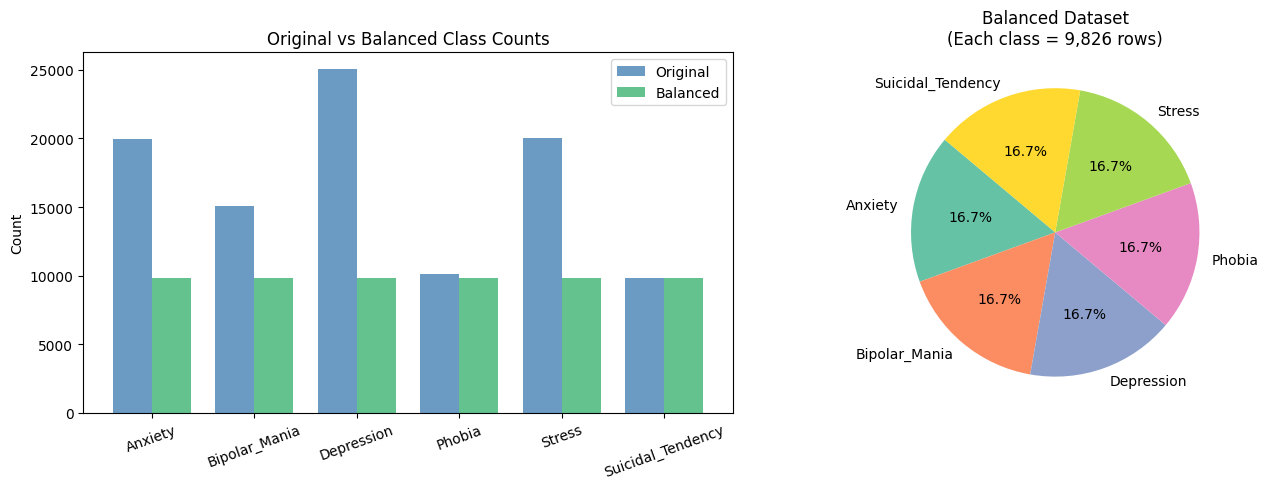

Imbalance ratio BEFORE: 2.55x
Imbalance ratio AFTER : 1.00x  ✓  (perfectly balanced)


In [5]:
# Verify balanced distribution
bal_counts  = df_balanced["target"].value_counts().sort_index()
orig_counts = df["target"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.38
x = range(len(orig_counts))
palette = sns.color_palette("Set2", len(orig_counts))

axes[0].bar([i - width/2 for i in x], orig_counts.values, width=width, label="Original", color="steelblue", alpha=0.8)
axes[0].bar([i + width/2 for i in x], bal_counts.values, width=width, label="Balanced", color="mediumseagreen", alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(orig_counts.index, rotation=20)
axes[0].set_title("Original vs Balanced Class Counts")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].pie(bal_counts.values, labels=bal_counts.index, autopct="%1.1f%%", colors=palette, startangle=140)
axes[1].set_title(f"Balanced Dataset\n(Each class = {n_min:,} rows)")

plt.tight_layout()
plt.show()

print(f"Imbalance ratio BEFORE: {orig_counts.max()/orig_counts.min():.2f}x")
print(f"Imbalance ratio AFTER : {bal_counts.max()/bal_counts.min():.2f}x  ✓  (perfectly balanced)")


In [6]:
# Save balanced dataset
output_path = "mental_health_balanced_dataset.csv"
df_balanced.to_csv(output_path, index=False)
print(f"Saved to  : {output_path}")
print(f"Shape     : {df_balanced.shape}")
print(f"Columns   : {df_balanced.columns.tolist()}")


Saved to  : mental_health_balanced_dataset.csv
Shape     : (58956, 66)
Columns   : ['profile', 'language', 'total_word_count', 'unique_word_count', 'ttr', 'positive_emotion_ratio', 'negative_emotion_ratio', 'fear_word_frequency', 'sadness_word_frequency', 'anger_word_frequency', 'uncertainty_word_frequency', 'filler_word_frequency', 'repetition_rate', 'rumination_phrase_frequency', 'semantic_coherence_score', 'language_model_perplexity', 'overall_sentiment_score', 'past_focus_ratio', 'present_focus_ratio', 'future_focus_ratio', 'noun_ratio', 'verb_ratio', 'adjective_ratio', 'adverb_ratio', 'avg_sentence_length', 'parse_tree_depth', 'topic_shift_frequency', 'self_reference_density', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb